# Funciones

Una función es código que se comporta como una caja negra: se le proporciona una entrada y devuelve una salida. Las funciones son esenciales porque permiten diseñar y usar algoritmos potencialmente complejos sin tener que estar al tanto de los detalles algorítmicos. 

Sólo hay que recordar el nombre de la función (recuerda que: se puede buscar  con `apropos()`  o anteponiendo `??` a la cadena de búsqueda), los argumentos de entrada y el tipo de salida que se generará.  

La mayor utilidad de R reside en la gran colección de funciones que ofrece.  
Por ejemplo, `library()`, `seq()`, `as.fractions()` son todas funciones. 

También puedes escribir tus propias funciones de R.  

Aquí mostramos los conceptos básicos sobre las funciones.

## Creando una función 
Una función tiene la siguiente estructura:  
<pre style="font-family: Courier New, monospace;">
    nombre_de_función <- function(argumentos) {
      cuerpo_de_función
      return(resultado)   
    } 
</pre>

Un ejemplo sencillo:
    

In [3]:
mi.func <- function(a, b) { 
    c  <- a * b
    return ( a + b -  c ) 
}

#Un vez creada la función  podemos usarla:
mi.func(5, 4)


[1] -11

In [4]:
# también podemos pasar argumentos por nombre o argumentos nombrados
mi.func(a=5, b=4)

[1] -11

## Funciones de R para generar números aleatorios

### `set.seed(k)`
Fija la semilla del generador de números aleatorios para reproducir exactamente los mismos resultados en diferentes ejecuciones.  
- **k**: número entero usado como semilla.  
**Utilidad:** Garantizar reproducibilidad en simulaciones, análisis estadísticos y experimentos computacionales.

---

### `rnorm(n, mean = 0, sd = 1)`
Genera números aleatorios con distribución normal.  
- **n**: cantidad de valores.  
- **mean**: media de la distribución.  
- **sd**: desviación estándar.  
**Utilidad:** Modelar fenómenos naturales y de error de medida; simulaciones donde se asume comportamiento gaussiano.

---

### `runif(n, min = 0, max = 1)`
Genera valores aleatorios con distribución uniforme.  
- **n**: cantidad de valores.  
- **min**: valor mínimo.  
- **max**: valor máximo.  
**Utilidad:** Generar puntos aleatorios en intervalos, inicializar variables en algoritmos, simulaciones sin sesgo.

---

### `rexp(n, rate = 1)`
Genera valores aleatorios con distribución exponencial.  
- **n**: cantidad de valores.  
- **rate**: parámetro λ, inverso de la media.  
**Utilidad:** Modelar tiempos entre eventos, como fallos de máquinas, llegadas en sistemas de servicio o procesos de vida media.

---

### `rbinom(n, size, prob)`
Genera valores con distribución binomial.  
- **n**: número de observaciones.  
- **size**: cantidad de ensayos por observación.  
- **prob**: probabilidad de éxito.  
**Utilidad:** Modelar número de éxitos en experimentos, simulación de resultados de ensayos repetidos (por ejemplo, lanzar una moneda varias veces).

---

### `rpois(n, lambda)`
Genera valores con distribución de Poisson.  
- **n**: cantidad de valores.  
- **lambda**: media del número de eventos.  
**Utilidad:** Modelar conteos de eventos en intervalos de tiempo, como llamadas a un centro de atención, clientes en colas, llegadas a un sistema o número de accidentes diarios.

---

### `rt(n, df)`
Genera valores con distribución t de Student.  
- **n**: cantidad de valores.  
- **df**: grados de libertad.  
**Utilidad:** Simulaciones cuando se trabaja con medias de muestras pequeñas o cuando se requiere una distribución con colas más pesadas que la normal. Si usamos muchos grados de libertad se asemeja mucho a la normal, Si usamos pocos grados de libertad tiene las "colas" con mayor peso.

---

### `rchisq(n, df)`
Genera valores con la distribución $\chi^2$ ( se lee Ki-Cuadrado en español o Chi-Square en inglés)

- **n**: cantidad de valores aleatorios que quieres generar.
- **df**: grados de libertad de la distribución chi-cuadrado.
**Utilidad:** Se usa para contrastar independencia entre variables categóricas y para evaluar si datos observados siguen una distribución teórica (¿cuán coherente es la variabilidad/varianza observada?)

---

### `sample(x, size, replace = FALSE)`
Selecciona valores al azar desde un vector o conjunto de enteros.  
- **x**: conjunto de valores.  
- **size**: cantidad a seleccionar.  
- **replace**: permite muestreo con reemplazo si es TRUE.  
**Utilidad:** Muestreo aleatorio, simulación de sorteos, permutaciones y reordenamientos de datos.



In [52]:
# fija la aleatoriedad. Así permite tener siempre los mismos números aleatorios
set.seed(11)

x_norm <- rnorm(5)
cat("Normal:",x_norm, "\r\n")

x_unif <- runif(5)
cat("Uniforme:",x_unif, "\r\n")

x_exp  <- rexp(5, rate = 1)
cat("Exponencial:",x_exp, "\r\n")

x_bin  <- rbinom(5, size = 10, prob = 0.5)
cat("Binomial:",x_bin, "\r\n")

x_pois <- rpois(5, lambda = 3)
cat("Poisson:",x_pois, "\r\n")

set.seed(NULL);
x_tstudent = rt(5, 1)
cat("T-Student:",x_tstudent, "\r\n")

x_chisq = rchisq(5, 2)
cat("\u03C7\u00B2:",x_chisq, "\r\n")

# 5 lanzamientos de moneda
x_sample <- sample(
  c("Cara", "Cruz"),   # posibles resultados
  size = 5,         # número de lanzamientos
  replace = TRUE,      # cada lanzamiento es independiente
  prob = c(0.5, 0.5)   # probabilidades
)
cat("sample:", x_sample, "\r\n")

Normal: -0.5910311 0.02659437 -1.516553 -1.362653 1.178489 
Uniforme: 0.1751129 0.4407503 0.907183 0.8510419 0.7339875 
Exponencial: 0.1473714 0.8024289 0.83435 1.148299 1.094541 
Binomial: 3 5 5 2 3 
Poisson: 2 3 2 2 2 
T-Student: 0.6702101 -0.8969045 -0.4908245 -1.504355 -0.5782292 
χ²: 0.01824777 2.708536 1.643945 1.048399 0.0484246 
sample: Cara Cruz Cruz Cruz Cara 


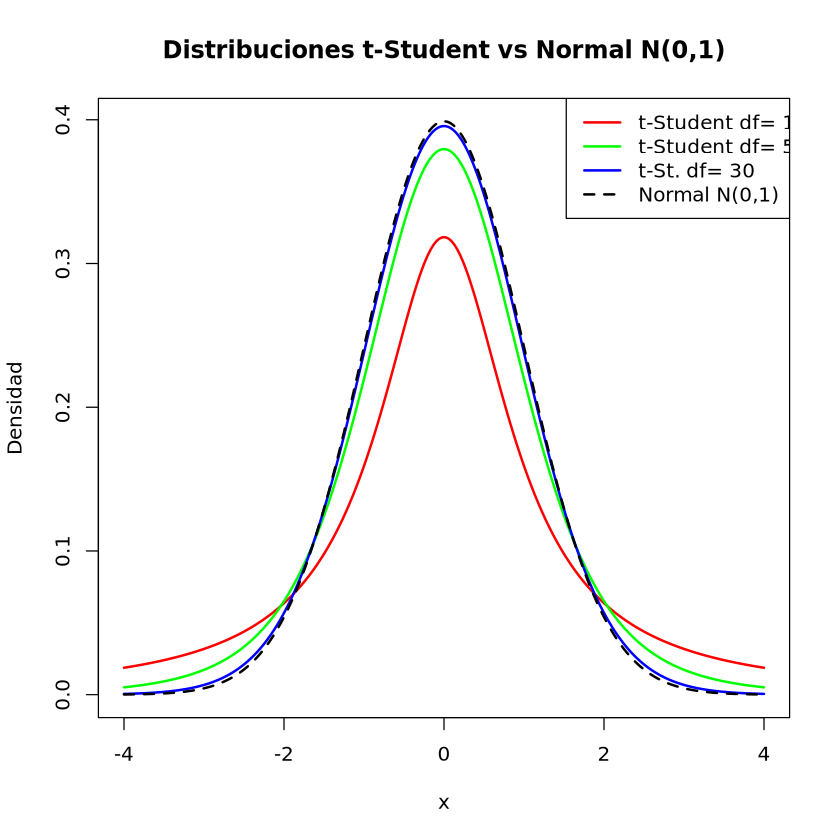

In [55]:
## Comparación de distribuciones t de Student con la normal

# Fijar semilla (opcional, no afecta a densidades)
set.seed(123)

# Rango de valores en el eje X
x <- seq(-4, 4, length.out = 400)

# Grados de libertad para las t-Student
df1 <- 1
df2 <- 5
df3 <- 30

# Densidades t-Student
y_t1  <- dt(x, df = df1)
y_t2  <- dt(x, df = df2)
y_t3  <- dt(x, df = df3)

# Densidad normal estándar
y_norm <- dnorm(x, mean = 0, sd = 1)

# Gráfico base con la primera t-Student
plot(x, y_t1, type = "l",
     col = "red",
     lwd = 2,
     ylim = c(0, max(y_t1, y_t2, y_t3, y_norm)),
     xlab = "x",
     ylab = "Densidad",
     main = "Distribuciones t-Student vs Normal N(0,1)")

# Añadir las otras curvas
lines(x, y_t2, col = "green", lwd = 2)
lines(x, y_t3, col = "blue",  lwd = 2)
lines(x, y_norm, col = "black", lwd = 2, lty = 2)

# Leyenda
legend("topright",
       legend = c(
         paste0("t-Student df= ", df1, " "),
         paste0("t-Student df= ", df2, " "),
         paste0("t-St. df= ", df3, " "),
         "Normal N(0,1)"
       ),
       col = c("red", "green", "blue", "black"),
       lwd = 2,
       lty = c(1, 1, 1, 2))


<h1 style="background-color: lightblue; padding: 10px;">
 Ejercicios
</h1>

1. Escriba una función que devuelva la suma de todos los números impares de a a b, donde a y b son los valores mínimo y máximo de una secuencia de enteros. Por ejemplo, si la función se llamara suma.impar, responderías la pregunta anterior con:
<pre style="font-family: Courier New, monospace;">
    suma.impar(1,100)
</pre>